# Biomedical Data Science 2025: Homework Assignment 1
### CBB & CPSC & S&DS (programming) Assignment

Due: March 26th, 11:59pm

#### Name:  Andrew Yu

# Instructions

* **You only need to write code between the `### START CODE HERE ###` and `### END CODE HERE ###` comments.**
* You may write code outside of these blocks, but it will not be graded.
* If you make use of any online resource please cite the source in the code comments.
* You may use some small utility functions directly, but notice that directly copying large chunks of codes (even with variable name replacement) are not allowed and will be considered as plagrism.
* After you are finished, **turn in the .ipynb file to canvas** (File->Download->Download .ipynb, then upload .ipynb files to assignment 1 in canvas).

# Part 0: Dataset

* In both Part 1 and Part 2, we will use a simulated dataset of DNA sequences of 50 bases long (chosen to be artificially short so that the data is easy to play around with), labeled 0 or 1 based on whether they bind to a transcription factor.
  * Sources of the simulated data: [paper link](https://www.nature.com/articles/s41588-018-0295-5)
* Our goal is to build a classifier - SVM (or your favorite ML model) in Part 1, CNN in Part 2 - that can predict whether a sequence binds to the protein and discover the short motif responsible for binding.

* (Spoiler alert: the true regulatory motif is *`CGACCGAACTCC`*. Of course, the model doesn't know this.)

Let's first load the data, which consists of DNA sequences and their corresponding labels.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

np.random.seed(0)

SEQUENCES_URL = 'https://raw.githubusercontent.com/abidlabs/deep-learning-genomics-primer/master/sequences.txt'

sequences = requests.get(SEQUENCES_URL).text.split('\n')
sequences = list(filter(None, sequences))  # This removes empty sequences.

# Let's print the first few sequences.
pd.DataFrame(sequences, index=np.arange(1, len(sequences)+1),
             columns=['Sequences']).head()

,Sequences
1,CCGAGGGCTATGGTTTGGAAGTTAGAACCCTGGGGCTTCTCGCGGA...
2,GAGTTTATATGGCGCGAGCCTAGTGGTTTTTGTACTTGTTTGTCGC...
3,GATCAGTAGGGAAACAAACAGAGGGCCCAGCCACATCTAGCAGGTA...
4,GTCCACGACCGAACTCCCACCTTGACCGCAGAGGTACCACCAGAGC...
5,GGCGACCGAACTCCAACTAGAACCTGCATAACTGGCCTGGGAGATA...


Similarly, we can go ahead and load the labels. In this case, the labels are structured as follows: a "1" indicates that a protein bound to the sequence, while a "0" indicates that the protein did not.

In [2]:
LABELS_URL = 'https://raw.githubusercontent.com/abidlabs/deep-learning-genomics-primer/master/labels.txt'

# Load labels from URL
labels = requests.get(LABELS_URL).text.split('\n')
labels = list(filter(None, labels))  # Remove empty entries

# Convert labels to NumPy array and ensure correct shape (B, 1)
labels = np.array(labels, dtype=np.float32).reshape(-1, 1)

print('Labels:\n', labels.T)

Labels:
 [[0. 0. 0. ... 0. 1. 1.]]


# Part 1: Predicting Transcription Factor Binding with k-mers and SVM (40 pts)

* In Part 1, you will implement a machine learning model using the strategy from the paper **Discriminative Prediction of Mammalian Enhancers from DNA Sequence** by Dongwon Lee, Rachel Karchin, and Michael A. Beer. [paper link](https://genome.cshlp.org/content/21/12/2167.full).

* This approach extracts k-mer features from DNA sequences and applies a Support Vector Machine (SVM) to predict transcription factor binding. While the paper focuses on SVM, **feel free to explore any ML model of your choice in this section**.

## 1.1 - Curate the Data


**Extracting k-mer Features for Classification**. We will first calculate k-mer frequencies for each DNA sequence in our dataset. These feature vectors will serve as inputs for our SVM (or any other machine learning model of your choice).  

For each sequence, we will count occurrences of all possible k-mers (subsequences of length k) and normalize these counts to obtain frequency-based feature representations. These feature vectors will then be used to train an ML model to separate positive (binding) and negative (non-binding) sequences. You can refer to Figure 1A of the paper for a clear diagram.


In [3]:
import numpy as np
from collections import Counter
from itertools import product

def kmer_transform(sequences, labels, k):
    """Convert DNA sequences into k-mer frequency tables for ML models."""
    kmers = [''.join(p) for p in product("ACGT", repeat=k)]
    X_transformed = []

    for seq in sequences:
        kmer_counts = Counter(seq[i:i+k] for i in range(len(seq) - k + 1))
        total_kmers = sum(kmer_counts.values())
        normalized_counts = [kmer_counts[kmer] / total_kmers if total_kmers > 0 else 0 for kmer in kmers]
        X_transformed.append(normalized_counts)

    return np.array(X_transformed), np.array(labels), kmers  # Return feature names

Start by splitting the dataset into training (80%) and test (20%) sets, ensuring the test set remains independent for final evaluation.

In [4]:
from sklearn.model_selection import train_test_split

k = 4  # Adjust as needed

# Transform sequences
X, y, feature_names = kmer_transform(sequences, labels, k)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check data shapes
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (1600, 256) Test shape: (400, 256)


## 1.2 - Train a classifier (20 pts)

In this step, you will train an SVM model to predict transcription factor binding using k-mer features we have extracted above. We will perform cross-validation (CV) and hyperparameter tuning to find the best-performing model.

**Instructions:**
* Define an ML model of your choise and perform hyperparameter search using `RandomizedSearchCV` or `GridSearchCV`, which applies 5-fold cross-validation (CV) within the training set to evaluate different hyperparameter combinations and select the best model.
* Select the best model based on CV performance, which is further used for final evaluation.
* Depending on the model you choose, here are some hyperparameter options you might want to consider:


```
# parameters search grid for model classes
rf_params = {'class_weight':['balanced'], 'n_estimators':[5, 10, 25, 50, 100],
              'min_impurity_decrease': [0, .1, .5], 'criterion': ['gini', 'entropy']}

svm_params = {'C':[0.25, 0.5, 1, 2], 'kernel':['linear', 'rbf', 'poly', 'sigmoid'],
              'degree':[2, 3, 4], 'class_weight':['balanced'],
              'probability': [True]}

xgb_params = {'n_estimators':[1, 2, 4, 8], 'booster':['gbtree', 'gblinear', 'dart'],
              'reg_alpha':[0.001, 0.01, 0.1, .5, 1], 'reg_lambda':[0.001, 0.01, 0.1, .5 ,1]}
```



In [5]:
from sklearn.svm import SVC  # you can add your model here
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

### START CODE HERE ###
svm_params = {'C':[0.25, 0.5, 1, 2], 'kernel':['linear', 'rbf', 'poly', 'sigmoid'],
              'degree':[2, 3, 4], 'class_weight':['balanced'],
              'probability': [True]}
svm = SVC()
grid = GridSearchCV(svm, svm_params, cv = 5, scoring = 'accuracy')
grid.fit(X_train, y_train.ravel())
best_svm = grid.best_estimator_
print("Best SVM Model:", best_svm)
### END CODE HERE ###

Best SVM Model: SVC(C=0.25, class_weight='balanced', degree=4, kernel='poly', probability=True)


## 1.3 - Evaluate (5 pts)

Test the model by making predictions on the test set and **printing the accuracy**.

In [6]:
from sklearn.metrics import accuracy_score

### START CODE HERE ###
y_pred = best_svm.predict(X_test)
print("Model Accuracy:", accuracy_score(y_test, y_pred))
### END CODE HERE ###

Model Accuracy: 0.995


## 1.4 - Feature importance (15 pts)



**Instructions:**
* Implement feature importance analysis using methods such as permutation test, SHAP, or any other suitable approach.
* Identify and report the top 5 k-mer features that contribute most to the model’s predictions.
* Compare the top k-mers with the true regulatory motif (*`CGACCGAACTCC`*) and report your observations.

In [7]:
### START CODE HERE ###
from sklearn.inspection import permutation_importance

result = permutation_importance(best_svm, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2)
sorted_idx = result.importances_mean.argsort()
top_5_features = [feature_names[i] for i in sorted_idx[-5:]]
print("Top 5 k-mer features:", top_5_features)

true_reg_motif = "CGACCGAACTCC"
print("True regulatory motif:", true_reg_motif)

print("Comparing top k-mers with the true regulatory motif:")
for feature in top_5_features:
  if feature in true_reg_motif:
    print(f"{feature} in {true_reg_motif}: Yes")
  else:
    print(f"{feature} in {true_reg_motif}: No")
### END CODE HERE ###

Top 5 k-mer features: ['ACTC', 'CTCC', 'AACT', 'ACCG', 'CCGA']
True regulatory motif: CGACCGAACTCC
Comparing top k-mers with the true regulatory motif:
ACTC in CGACCGAACTCC: Yes
CTCC in CGACCGAACTCC: Yes
AACT in CGACCGAACTCC: Yes
ACCG in CGACCGAACTCC: Yes
CCGA in CGACCGAACTCC: Yes


When having a k-mer length of 4, all the top k-mer features are present in the true regulatory motif, which would make sense when we're searching for multiple k-mer matches with the true regulatory motif.

# Part 2: A neural network for finding transcription factor binding sites

The following protocol is adapted from a colab notebook for one of our discussion section papers: **A Primer on Deep Learning in Genomics** (*Nature Genetics, 2018*) by James Zou, Mikael Huss, Abubakar Abid, Pejman Mohammadi, Ali Torkamani & Amalio Telentil. [paper link](https://www.nature.com/articles/s41588-018-0295-5).

In this section, we will build a convolutional neural network (CNN) to identify binding motifs in DNA sequences. The model will predict whether a given sequence binds to a transcription factor, learning from labeled training data where sequences are marked as 0 (non-binding) or 1 (binding).

We will use the same simulated dataset introduced earlier, where sequences are 50 bases long and contain an unknown regulatory motif responsible for binding. The goal is to train a CNN that can recognize key sequence patterns and extract important features from the data.

(Spoiler alert: the true regulatory motif is *`CGACCGAACTCC`*. Of course, the neural network doesn't know this.)


## 2.0 - Instructions

**Instructions for part 2**:
* Sections 2.1-2.4 will preprocess data, set up a basic network, and run evaluation for you. For most cells, you only need to read and run them, except for the `train_one_epoch()` function.
* In section 2.5 you will be doing hyperparameter tuning to optimize this model. You may edit code in all sections, but **only code between the `### START CODE HERE ###` and `### END CODE HERE ###` will be graded**.

## 2.1 - Curate the Data

In order to train the neural network, we must preprocess the data, which consists of DNA sequences and their corresponding labels. By processing this data, the network will learn to distinguish sequences that bind to the transcription factor from those that do not. We will split the data into three different sub-datasets:

(1) Training dataset: a dataset used to fit the parameters of a model or to define the weights of connections between neurons of a neural network.

(2) Validation dataset: a second dataset used to minimize overfitting. The weights of the network are not adjusted with this data set. After each training cycle, if the accuracy over the training data set increases, but the accuracy over the validation data set stays the same or decreases, then there is overfitting on the neural network.

(3) Testing dataset: is a third dataset not included in the training nor validation data sets. After all the training and validation cycles are complete, this dataset is used only for testing the final solution in order to measure the actual predictive power of the neural network on new examples.


In [8]:
# import the pytorch library into environment and check its version
import torch
print("Using torch", torch.__version__)

# colab provides gpu; the training data is relatively small so cpu will work for hw1
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Using torch 2.2.2
Device: cpu


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

torch.manual_seed(0)
np.random.seed(0)

SEQUENCES_URL = 'https://raw.githubusercontent.com/abidlabs/deep-learning-genomics-primer/master/sequences.txt'

sequences = requests.get(SEQUENCES_URL).text.split('\n')
sequences = list(filter(None, sequences))  # This removes empty sequences.

# Let's print the first few sequences.
pd.DataFrame(sequences, index=np.arange(1, len(sequences)+1),
             columns=['Sequences']).head()

,Sequences
1,CCGAGGGCTATGGTTTGGAAGTTAGAACCCTGGGGCTTCTCGCGGA...
2,GAGTTTATATGGCGCGAGCCTAGTGGTTTTTGTACTTGTTTGTCGC...
3,GATCAGTAGGGAAACAAACAGAGGGCCCAGCCACATCTAGCAGGTA...
4,GTCCACGACCGAACTCCCACCTTGACCGCAGAGGTACCACCAGAGC...
5,GGCGACCGAACTCCAACTAGAACCTGCATAACTGGCCTGGGAGATA...


The next  step is to organize the data into a format that can be passed into a deep learning algorithm. Most deep learning algorithms accept data in the form of vectors or matrices (or more generally, tensors).

To get each DNA sequence in the form of a matrix, we use _one-hot encoding_, which encodes every base in a sequence in the form of a 4-dimensional vector, with a separate dimension for each base. We place a "1" in the dimension corresponding to the base found in the DNA sequence, and "0"s in all other slots. We then concatenate these 4-dimensional vectors together along the bases in the sequence to form a matrix.

In the cell below, we one-hot encode the simulated DNA sequences, and show an example of what the one-hot encoded sequence looks like:

In [10]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# The LabelEncoder encodes a sequence of bases as a sequence of integers.
integer_encoder = LabelEncoder()

# The OneHotEncoder converts an array of integers to a sparse matrix where
# each row corresponds to one possible value of each feature.
one_hot_encoder = OneHotEncoder(categories='auto')
input_features = []

for sequence in sequences:
  integer_encoded = integer_encoder.fit_transform(list(sequence))
  integer_encoded = np.array(integer_encoded).reshape(-1, 1)
  one_hot_encoded = one_hot_encoder.fit_transform(integer_encoded)
  input_features.append(one_hot_encoded.toarray())

np.set_printoptions(threshold=40)
input_features = np.stack(input_features)
print("Example sequence\n-----------------------")
print('DNA Sequence #1:\n',sequences[0][:10],'...',sequences[0][-10:])
print('One hot encoding of Sequence #1:\n',input_features[0].T)

Example sequence
-----------------------
DNA Sequence #1:
 CCGAGGGCTA ... CGCGGACACC
One hot encoding of Sequence #1:
 [[0. 0. 0. ... 1. 0. 0.]
 [1. 1. 0. ... 0. 1. 1.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


Similar to Part 1, the labels are structured as follows: a "1" indicates that a protein bound to the sequence, while a "0" indicates that the protein did not.

In [11]:
LABELS_URL = 'https://raw.githubusercontent.com/abidlabs/deep-learning-genomics-primer/master/labels.txt'

# Load labels from URL
labels = requests.get(LABELS_URL).text.split('\n')
labels = list(filter(None, labels))  # Remove empty entries

# Convert labels to NumPy array and ensure correct shape (B, 1)
input_labels = np.array(labels, dtype=np.float32).reshape(-1, 1)

print('Labels:\n', input_labels.T)

Labels:
 [[0. 0. 0. ... 0. 1. 1.]]


In [12]:
# Convert to PyTorch tensor
input_features = torch.tensor(input_features, dtype=torch.float32)
input_labels = torch.tensor(input_labels, dtype=torch.float32)

input_features.shape, input_labels.shape

(torch.Size([2000, 50, 4]), torch.Size([2000, 1]))

We split the data into training, validation, and test sets in one step. The training set is used to train the model, the validation set helps tune hyperparameters and monitor overfitting, and the test set provides an unbiased evaluation of final model performance on unseen data.

In [13]:
from torch.utils.data import TensorDataset, DataLoader, random_split

# Create a dataset from tensors
dataset = TensorDataset(input_features, input_labels)

# Define split sizes: 70% train, 10% val, 20% test
train_size = int(0.7 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size  # Ensure all data is used

# Perform split
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

## 2.2 - Model architecture

![alt text](https://github.com/abidlabs/deep-learning-genomics-primer/blob/master/Screenshot%20from%202018-08-01%2020-31-49.png?raw=true)

Next, we choose a neural network architecture to train the model. In this tutorial, we choose a simple 1D convolutional neural network (CNN), which is commonly used in deep learning for functional genomics applications.

A CNN learns to recognize patterns that are generally invariant across space, by trying to match the input sequence to a number of learnable "filters" of a fixed size. In our dataset, the filters will be motifs within the DNA sequences. The CNN may then learn to combine these filters to recognize a larger structure (e.g. the presence or absence of a transcription factor binding site).

We will use the deep learning library `Pytorch`, which is one of the most popular deep learning libraries. See more introduction in https://pytorch.org/. The CNN we generate in this example consists of the following layers:

- _Conv1D_: We define our convolutional layer to have 32 filters of size 12 bases.

- _MaxPooling1D_: After the convolution, we use a pooling layer to down-sample the output of the each of the 32 convolutional filters. Though not always required, this is a typical form of non-linear down-sampling used in CNNs.

- _Flatten_: This layer flattens the output of the max pooling layer, combining the results of the convolution and pooling layers across all 32 filters.

- _Dense_: The first Dense tensor creates a layer (dense_1) that compresses the representation of the flattened layer, resulting in smaller layer with 16 tensors, and the second Dense function converges the tensors into the output layer (dense_2) that consists of the two possible response values (0 or 1).


In [14]:
import torch
import torch.nn as nn
import torch.optim as optim

class ConvNet(nn.Module):
    def __init__(self, seq_len,
                 num_filters=32, filter_size=12):
        super(ConvNet, self).__init__()
        self.model = nn.Sequential(
            nn.Conv1d(in_channels=4, out_channels=num_filters, kernel_size=filter_size, stride=1),
            nn.MaxPool1d(kernel_size=4),
            nn.Flatten(),
            nn.Linear(
                num_filters * ((seq_len - filter_size + 1) // 4),  # Output dim after Conv + Pooling - can refer to "shape" section: https://pytorch.org/docs/stable/generated/torch.nn.Conv1d.html
                16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)  # Change shape from (B, 50, 4) → (B, 4, 50) for Conv1d
        return self.model(x)

## 2.3 - Train

In [15]:
# Define accuracy computation for binary classification
def compute_accuracy(output, targets):
    """Calculates accuracy for binary classification."""
    output = output.detach()  # Detach from computation graph
    predicted = (output > 0.5).float()
    return (predicted == targets).float().mean().item()

Now, we will implement a function to train the model for one epoch. The function takes in training data, computes loss and accuracy, and updates model parameters. Fill in the missing steps to complete the training process.

In [16]:
# @title finish the function here (10 pts)

def train_one_epoch(model, train_loader, criterion, optimizer, epoch, num_epochs):
    """Trains the model for one epoch and returns the average loss and accuracy."""
    model.train()
    epoch_loss, epoch_acc = 0, 0

    for batch_idx, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        ### START CODE HERE ###
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        ### END CODE HERE ###

        epoch_acc += compute_accuracy(outputs, labels)
        epoch_loss += loss.detach().item()

    avg_loss = epoch_loss / len(train_loader)
    avg_acc = epoch_acc / len(train_loader)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}]  loss: {avg_loss:.4f}  train_acc: {avg_acc:.3f}")

    return avg_loss, avg_acc

In [17]:
def evaluate(model, val_loader, criterion):
    """Evaluates the model on the validation set and returns loss & accuracy."""
    model.eval()  # Set model to evaluation mode (disable dropout, no gradient updates)

    total_loss, total_acc = 0, 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            val_outputs = model(inputs)
            total_loss += criterion(val_outputs, labels.float()).item()
            total_acc += compute_accuracy(val_outputs, labels)

    avg_loss = total_loss / len(val_loader)
    avg_acc = total_acc / len(val_loader)

    return avg_loss, avg_acc

Define the model parameters and initialize model.

In [18]:
# Define model parameters
seq_len = 50
num_filters = 32  # num of filters applied
filter_size = 12  # filter dim

# Instantiate model
model = ConvNet(seq_len=seq_len, num_filters=num_filters, filter_size=filter_size)
model.to(device)
print(model)

ConvNet(
  (model): Sequential(
    (0): Conv1d(4, 32, kernel_size=(12,), stride=(1,))
    (1): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (2): Flatten(start_dim=1, end_dim=-1)
    (3): Linear(in_features=288, out_features=16, bias=True)
    (4): ReLU()
    (5): Linear(in_features=16, out_features=1, bias=True)
    (6): Sigmoid()
  )
)


In [19]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Track training & validation metrics
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

# Training loop
num_epochs = 50
for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, epoch, num_epochs)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    # Store metrics
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

Epoch [10/50]  loss: 0.0521  train_acc: 0.990
Epoch [20/50]  loss: 0.0087  train_acc: 1.000
Epoch [30/50]  loss: 0.0027  train_acc: 1.000
Epoch [40/50]  loss: 0.0012  train_acc: 1.000
Epoch [50/50]  loss: 0.0007  train_acc: 1.000


It is important to monitor the training and validation loss throughout the learning process. A steadily decreasing validation loss indicates effective learning. Once the loss for the validation set stops improving or gets worse throughout the learning cycles, it is time to stop training because the model has already converged and may be just overfitting.

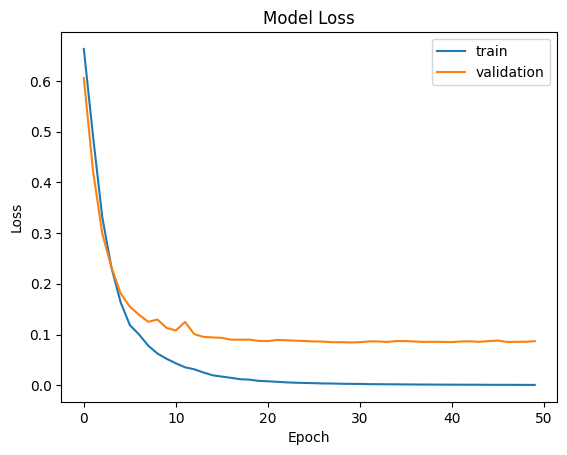

In [20]:
# Plot Loss Curve
plt.figure()
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='validation')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

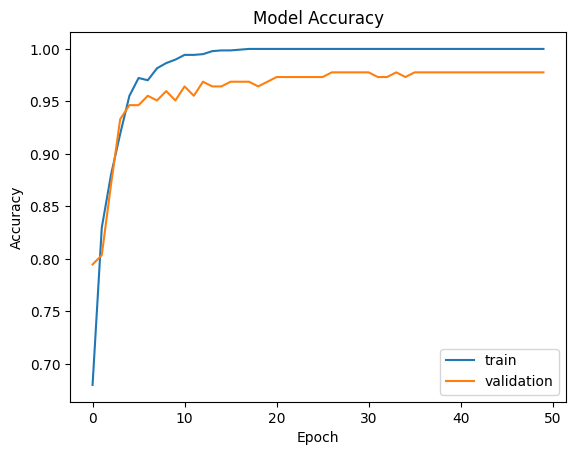

In [21]:
# Plot Accuracy Curve (to match TensorFlow visualization)
plt.figure()
plt.plot(train_accuracies, label='train')
plt.plot(val_accuracies, label='validation')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

## 2.3 -  Evaluate

![alt text](https://github.com/abidlabs/deep-learning-genomics-primer/blob/master/Screenshot%20from%202018-08-01%2020-32-12.png?raw=true)

The best way to evaluate whether the network has learned to classify sequences is to evaluate its performance on a fresh test set consisting of data that it has not observed at all during training. Here, we evaluate the model on the test set and plot the results as a confusion matrix. Nearly every test sequence should be correctly classified.

Confusion matrix:
 [[201   3]
 [  1 195]]


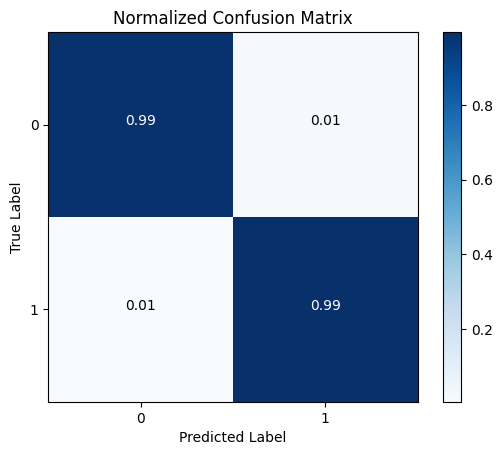

In [22]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import itertools
import torch

model.eval()

all_preds, all_labels = [], []

# Iterate over test_loader to collect predictions and labels
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        preds = (outputs > 0.5).long()
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

all_preds = torch.cat(all_preds).numpy().flatten()
all_labels = torch.cat(all_labels).numpy().flatten()

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)
print('Confusion matrix:\n', cm)

# Normalize confusion matrix
cm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

# Plot Confusion Matrix
plt.imshow(cm, cmap=plt.cm.Blues)
plt.title('Normalized Confusion Matrix')
plt.colorbar()

## Update: swap x, y-labels: rows represent true labels; columns represent predictions
plt.ylabel("True Label")
plt.xlabel("Predicted Label")

plt.xticks([0, 1]); plt.yticks([0, 1])
plt.grid(False)

# Annotate values
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], '.2f'),
             horizontalalignment='center',
             color='white' if cm[i, j] > 0.5 else 'black')

plt.show()

In [23]:
cm

array([[0.98529412, 0.01470588],
       [0.00510204, 0.99489796]])

## 2.4 - Interpret

![alt text](https://github.com/abidlabs/deep-learning-genomics-primer/blob/master/Screenshot%20from%202018-08-01%2020-32-31.png?raw=true)

Your results so far should allow you to conclude that the neural network is quite effective in learning to distinguish sequences that bind the protein from sequences that do not. But can we understand _why_ the neural network classifies a training point in the way that it does? To do so, we can compute a simple _saliency map_, which is the gradient of the model's prediction with respect to each individual nucleotide.

In other words, the saliency maps shows how the output response value changes with respect to a small changes in input nucleotide sequence. All the positive values in the gradients tell us that a small change to that nucleotide will change the output value. Hence, visualizing these gradients for a given input sequence, should provide some clues about what nucleotides form the binding motive that we are trying to identify.

In genomics, we typically visualize gradients only for the bases present in the sequence, a method known as input-masked gradients or Grad × Input in some studies.

In [24]:
# @title finish the function here (bonus 5 pts)
# you don't need this function for the rest of the assignment
def compute_saliency_map(model, input_seq):
    """
    Computes the saliency map (Gradient × Input) for a given input sequence.
    """
    model.eval()
    input_seq = input_seq.to(device).unsqueeze(0)  # Add batch dimension: (1, 50, 4)
    input_seq.requires_grad_(True)  # Enable gradient tracking - Note here we compute grad. wrt input!

    ### START CODE HERE ###
    # compute **grads**: the output should have shape (50, 4), representing gradient importance at each position for each nucleotide (A, C, G, T).

    # Hint: A function commonly used in backpropagation can be applied here, but instead of computing gradients with respect to model parameters,
    # we compute them with respect to the input sequence.

    output = model(input_seq)
    output_sum = output.sum()
    grads = torch.autograd.grad(output_sum, input_seq, retain_graph=True)[0]
    grads = grads.squeeze(0)

    ### END CODE HERE ###

    # saliency = torch.clamp(grads * input_seq.squeeze(0).cpu().detach(), min=0).sum(dim=1)
    saliency = torch.clamp(grads.cpu() * input_seq.squeeze(0).cpu().detach(), min=0).sum(dim=1)

    # Normalize to [0,1] range: min-max normalization
    saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-10)

    return saliency, grads

In [25]:
# let's visualize the saliency map of an example sequence (note, we are normally interested in positive example)
seq_idx = 1999

seq_oi = input_features[seq_idx]   # this is a positive example
print(input_labels[seq_idx])

saliency_map, grads = compute_saliency_map(model, seq_oi)

tensor([1.])


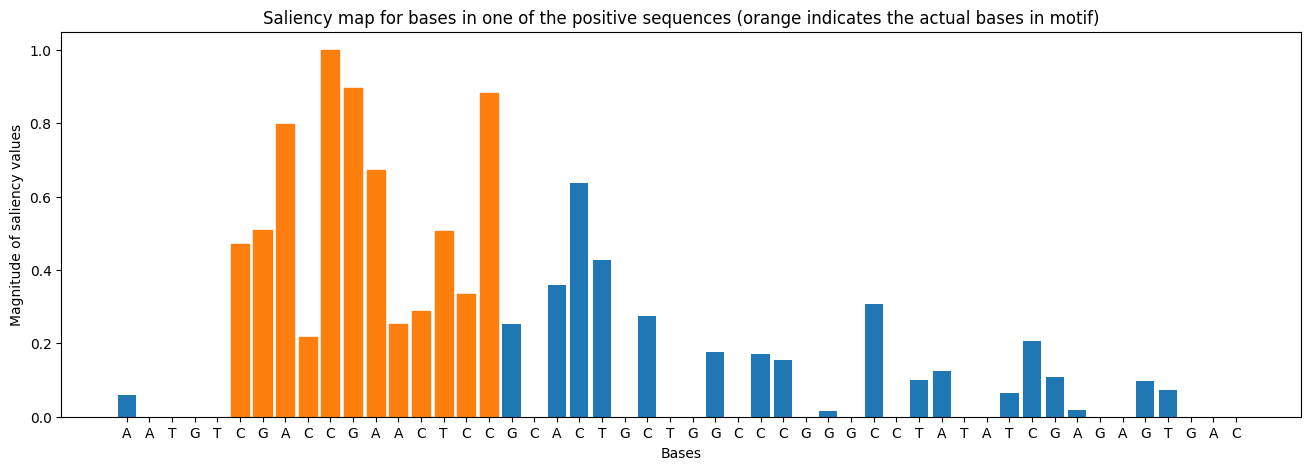

In [26]:
plt.figure(figsize=[16,5])
barlist = plt.bar(np.arange(len(saliency_map)), saliency_map)
[barlist[i].set_color('C1') for i in range(5,17)]  # Change the coloring here if you change the sequence index.
plt.xlabel('Bases')
plt.ylabel('Magnitude of saliency values')
plt.xticks(np.arange(len(saliency_map)), list(sequences[1999]));
plt.title('Saliency map for bases in one of the positive sequences'
          ' (orange indicates the actual bases in motif)');

The results above should show high saliency values for the bases _CGACCGAACTCC_ appearing in the DNA sequence. If you recall from the top of the document, this is exactly the motif that we embedded in the positive sequences! The raw saliency values may be non-zero for other bases as well -- the gradient-based saliency map method is not perfect, and there other more complex interpretation methods that are used in practice to obtain better results.  


Here is an alternative way for visualizing `Grad X Input`.

In [27]:
!pip install logomaker
import logomaker
import seaborn as sns
import pandas as pd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 49.3 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.11 -m pip install --upgrade pip


In [28]:
# helper function for plotting
# copied from basenji model repo: https://github.com/calico/basenji/blob/master/jupyter/basenji_sat_vcf_viz.ipynb
def plot_logo(scores, seq_1hot, viz_len=None, ymin=-np.inf, ymax=np.inf):
    if viz_len is not None and viz_len < seq_1hot.shape[0]:
        mid_pos = seq_1hot.shape[0]//2
        viz_start = mid_pos - viz_len//2
        viz_end = viz_start + viz_len
        scores = scores[viz_start:viz_end]
        seq_1hot = seq_1hot[viz_start:viz_end]
    scores = np.clip(scores, ymin, ymax)

    fig, axs = plt.subplots(2, 1, figsize=(30,3.5))
    seq_df = pd.DataFrame(seq_1hot*scores, columns=['A','C','G','T'])
    seq_logo = logomaker.Logo(seq_df, ax=axs[0])
    if not np.isinf(ymin):
        seq_logo.ax.set_ylim(bottom=ymin)
    if not np.isinf(ymax):
        seq_logo.ax.set_ylim(top=ymax)

    sns.heatmap(scores.T, center=0, cbar=False, ax=axs[1])
    axs[1].set_yticklabels('ACGT')

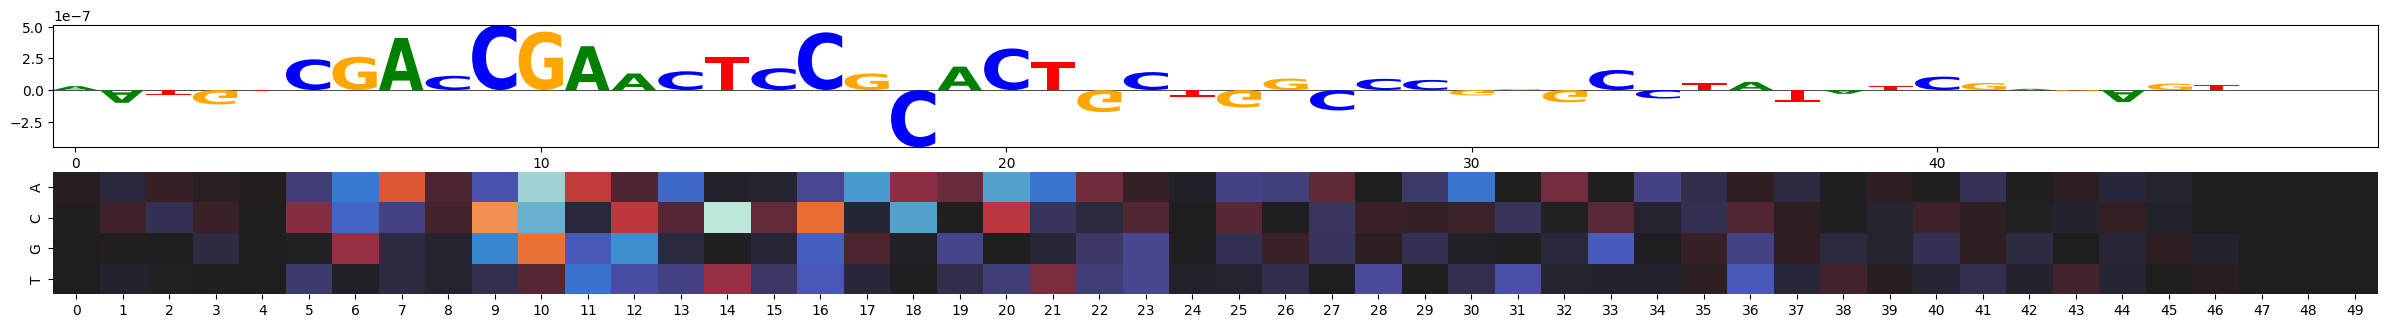

In [29]:
input_seq = input_features[seq_idx]  # One-hot encoded (50, 4)
# plot_logo(grads.numpy(), input_seq.numpy())
plot_logo(grads.squeeze(0).cpu().detach().numpy(), input_seq.cpu().detach().numpy())

Again, note that our real motif in the data is highlighted in the saliency map: _CGACCGAACTCC_.

## 2.5 - Hyperparameter tuning

For the following problems, you can (and should) copy/reuse any of the code from above.

### a. loss function (15 pts)
The base model above uses `'binary_crossentropy'`(BCE) as its loss function. Re-train the model using `'mean_squared_error'` (MSE) and `'hinge'` as loss instead. Show, in a plot, how the precision and recall are affected on the test set for each of the losses (BCE,MSE, and hinge).

Epoch [10/50]  loss: 0.0752  train_acc: 0.983
Epoch [20/50]  loss: 0.0177  train_acc: 0.999
Epoch [30/50]  loss: 0.0055  train_acc: 1.000
Epoch [40/50]  loss: 0.0024  train_acc: 1.000
Epoch [50/50]  loss: 0.0013  train_acc: 1.000
BCE - Precision: 0.9749, Recall: 0.9898
Epoch [10/50]  loss: 0.0177  train_acc: 0.985
Epoch [20/50]  loss: 0.0031  train_acc: 0.999
Epoch [30/50]  loss: 0.0007  train_acc: 1.000
Epoch [40/50]  loss: 0.0003  train_acc: 1.000
Epoch [50/50]  loss: 0.0002  train_acc: 1.000
MSE - Precision: 0.9700, Recall: 0.9898
Epoch [10/50]  loss: 0.0563  train_acc: 0.986
Epoch [20/50]  loss: 0.0072  train_acc: 0.998
Epoch [30/50]  loss: 0.0006  train_acc: 1.000
Epoch [40/50]  loss: 0.0000  train_acc: 1.000
Epoch [50/50]  loss: 0.0000  train_acc: 1.000
hinge - Precision: 0.9848, Recall: 0.9949


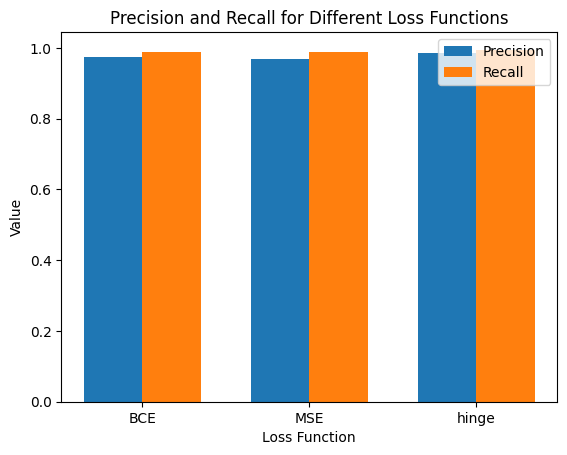

In [31]:
### START CODE HERE ###
from sklearn.metrics import precision_score, recall_score

# --- Logit-output variant of ConvNet, used only for hinge loss ---
class ConvNetLogits(nn.Module):
    def __init__(self, seq_len, num_filters=32, filter_size=12):
        super(ConvNetLogits, self).__init__()
        self.model = nn.Sequential(
            nn.Conv1d(in_channels=4, out_channels=num_filters, kernel_size=filter_size, stride=1),
            nn.MaxPool1d(kernel_size=4),
            nn.Flatten(),
            nn.Linear(num_filters * ((seq_len - filter_size + 1) // 4), 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        return self.model(x)


def hinge_loss(output, labels):
    """Standard SVM-style hinge loss. labels must be in {-1, +1}."""
    y = 2 * labels - 1  # {0,1} -> {-1,+1}
    return torch.clamp(1 - y * output, min=0).mean()


def train_one_epoch_hinge(model, train_loader, optimizer, epoch, num_epochs):
    model.train()
    epoch_loss, epoch_acc = 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = hinge_loss(outputs, labels)
        loss.backward()
        optimizer.step()

        preds = (outputs > 0).float()
        epoch_acc += (preds == labels).float().mean().item()
        epoch_loss += loss.detach().item()

    avg_loss, avg_acc = epoch_loss / len(train_loader), epoch_acc / len(train_loader)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}]  loss: {avg_loss:.4f}  train_acc: {avg_acc:.3f}")
    return avg_loss, avg_acc


def evaluate_hinge(model, val_loader):
    model.eval()
    total_loss, total_acc = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            total_loss += hinge_loss(outputs, labels).item()
            preds = (outputs > 0).float()
            total_acc += (preds == labels).float().mean().item()
    return total_loss / len(val_loader), total_acc / len(val_loader)


def prec_rec_eval_hinge(model, test_loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            output = model(inputs)
            preds = (output > 0).long()
            y_true.extend(labels.cpu())
            y_pred.extend(preds.cpu())
    return precision_score(y_true, y_pred), recall_score(y_true, y_pred)


def training_loop(model, train_loader, criterion, optimizer, num_epochs):
    for epoch in range(num_epochs):
        train_one_epoch(model, train_loader, criterion, optimizer, epoch, num_epochs)
        evaluate(model, val_loader, criterion)


def prec_rec_eval(model, test_loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            output = model(inputs)
            preds = (output > 0.5).long()
            y_true.extend(labels.cpu())
            y_pred.extend(preds.cpu())
    return precision_score(y_true, y_pred), recall_score(y_true, y_pred)


loss_names = ['BCE', 'MSE', 'hinge']
precisions, recalls = [], []

for criterion_name in loss_names:
    if criterion_name == 'hinge':
        model = ConvNetLogits(seq_len=seq_len, num_filters=num_filters, filter_size=filter_size)
        model.to(device)
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        for epoch in range(num_epochs):
            train_one_epoch_hinge(model, train_loader, optimizer, epoch, num_epochs)
            evaluate_hinge(model, val_loader)
        precision, recall = prec_rec_eval_hinge(model, test_loader)
    else:
        criterion = nn.BCELoss() if criterion_name == 'BCE' else nn.MSELoss()
        model = ConvNet(seq_len=seq_len, num_filters=num_filters, filter_size=filter_size)
        model.to(device)
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        training_loop(model, train_loader, criterion, optimizer, num_epochs)
        precision, recall = prec_rec_eval(model, test_loader)

    precisions.append(precision)
    recalls.append(recall)
    print(f"{criterion_name} - Precision: {precision:.4f}, Recall: {recall:.4f}")

plt.figure()
index = np.arange(len(loss_names))
bar_width = 0.35
plt.bar(index, precisions, bar_width, label='Precision')
plt.bar(index + bar_width, recalls, bar_width, label='Recall')
plt.xlabel('Loss Function')
plt.ylabel('Value')
plt.title('Precision and Recall for Different Loss Functions')
plt.xticks(index + bar_width / 2, loss_names)
plt.legend()
plt.show()
### END CODE HERE ###

### b. explain (10 pts)
Explain why the binary cross entropy loss is more appropriate than MSE or hinge loss for this classification problem


BCE loss is more appropriate for this classification problem because the only possible outputs are 0 or 1 (no protein binding or protein binding). BCE is designed for these scenarios, as it measures classification models where the output can only be 0 or 1. MSE loss is designed for regression tasks since it wants to minimize the square difference between predicted and actual values. Since this classification problem is binary and not continuous, MSE loss is not as appropriate for the problem as BCE loss. Hinge loss is generally used in SVMs, as it tries to maximize the margin between classes rather than create output probabilities (which is what BCE loss does for the CNN).

### c. number of filters (10 pts)

Keeping all other parameters equal, vary the number of filters in the first convolutional layer from 1 to 64, in powers of 2, and show in a plot how the precision and recall are affected on the test set.

Epoch [10/50]  loss: 0.4438  train_acc: 0.781
Epoch [20/50]  loss: 0.3360  train_acc: 0.850
Epoch [30/50]  loss: 0.2640  train_acc: 0.890
Epoch [40/50]  loss: 0.2184  train_acc: 0.916
Epoch [50/50]  loss: 0.1883  train_acc: 0.930
Filters: 1 - Precision: 0.8744, Recall: 0.9235
Epoch [10/50]  loss: 0.3691  train_acc: 0.846
Epoch [20/50]  loss: 0.2469  train_acc: 0.899
Epoch [30/50]  loss: 0.1912  train_acc: 0.925
Epoch [40/50]  loss: 0.1477  train_acc: 0.951
Epoch [50/50]  loss: 0.1193  train_acc: 0.960
Filters: 2 - Precision: 0.8714, Recall: 0.9337
Epoch [10/50]  loss: 0.2121  train_acc: 0.929
Epoch [20/50]  loss: 0.0949  train_acc: 0.970
Epoch [30/50]  loss: 0.0620  train_acc: 0.980
Epoch [40/50]  loss: 0.0427  train_acc: 0.988
Epoch [50/50]  loss: 0.0270  train_acc: 0.996
Filters: 4 - Precision: 0.9507, Recall: 0.9847
Epoch [10/50]  loss: 0.1151  train_acc: 0.966
Epoch [20/50]  loss: 0.0454  train_acc: 0.990
Epoch [30/50]  loss: 0.0191  train_acc: 0.998
Epoch [40/50]  loss: 0.0086  tr

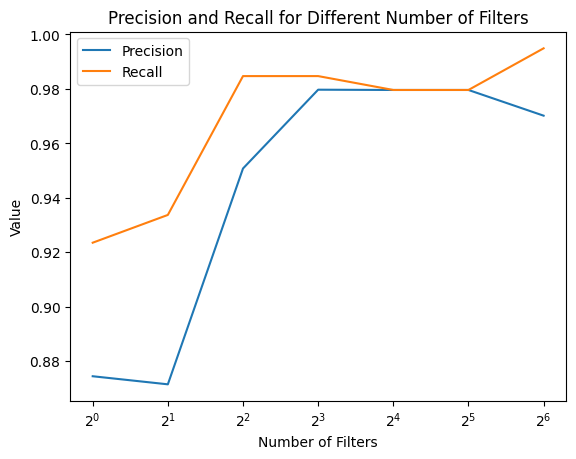

In [ ]:
filters = 2**np.arange(7)

### START CODE HERE ###
# I will be using a BCE loss criterion for the models here
criterion = nn.BCELoss()
num_epochs = 50
precisions, recalls = [], []
for num_filters in filters:
  model = ConvNet(seq_len=seq_len, num_filters=num_filters, filter_size=filter_size)
  model.to(device)
  optimizer = optim.Adam(model.parameters(), lr=0.001)
  training_loop(model, train_loader, criterion, optimizer, num_epochs)
  precision, recall = prec_rec_eval(model, test_loader)
  precisions.append(precision)
  recalls.append(recall)
  print(f"Filters: {num_filters} - Precision: {precision:.4f}, Recall: {recall:.4f}")

plt.figure()
plt.plot(filters, precisions, label='Precision')
plt.plot(filters, recalls, label='Recall')
plt.xscale('log', base = 2)
plt.xlabel('Number of Filters')
plt.ylabel('Value')
plt.title('Precision and Recall for Different Number of Filters')
plt.legend()
plt.show()
### END CODE HERE ###

### d. kernal size (10 pts)

Keeping all other parameters equal, vary the size of the filter (kernel size) in the first convolutional layer from 1 to 32, in powers of 2, and show in a plot how the precision and recall are affected on the test set.

Epoch [10/50]  loss: 0.5300  train_acc: 0.746
Epoch [20/50]  loss: 0.4750  train_acc: 0.784
Epoch [30/50]  loss: 0.4580  train_acc: 0.786
Epoch [40/50]  loss: 0.4388  train_acc: 0.793
Epoch [50/50]  loss: 0.4121  train_acc: 0.809
Kernel Size: 1 - Precision: 0.7398, Recall: 0.7398
Epoch [10/50]  loss: 0.2727  train_acc: 0.893
Epoch [20/50]  loss: 0.1816  train_acc: 0.938
Epoch [30/50]  loss: 0.1233  train_acc: 0.966
Epoch [40/50]  loss: 0.0856  train_acc: 0.975
Epoch [50/50]  loss: 0.0600  train_acc: 0.984
Kernel Size: 2 - Precision: 0.9242, Recall: 0.9337
Epoch [10/50]  loss: 0.1188  train_acc: 0.970
Epoch [20/50]  loss: 0.0423  train_acc: 0.993
Epoch [30/50]  loss: 0.0148  train_acc: 1.000
Epoch [40/50]  loss: 0.0060  train_acc: 1.000
Epoch [50/50]  loss: 0.0032  train_acc: 1.000
Kernel Size: 4 - Precision: 0.9602, Recall: 0.9847
Epoch [10/50]  loss: 0.0694  train_acc: 0.984
Epoch [20/50]  loss: 0.0150  train_acc: 0.999
Epoch [30/50]  loss: 0.0051  train_acc: 1.000
Epoch [40/50]  loss

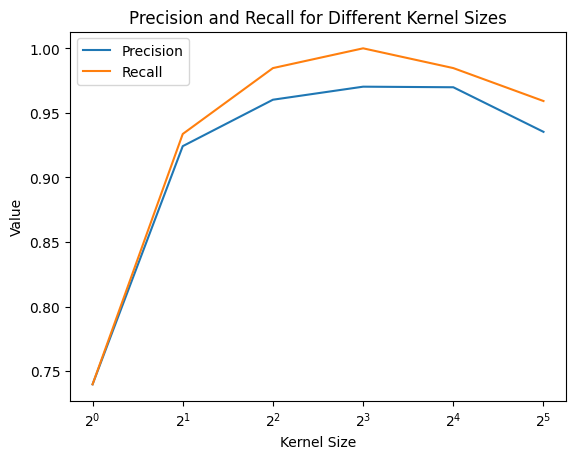

In [ ]:
kernel_sizes = 2**np.arange(6)

### START CODE HERE ###
# I will be using a BCE loss criterion for the models here
criterion = nn.BCELoss()
num_epochs = 50
num_filters = 32
precisions, recalls = [], []
for kernel_size in kernel_sizes:
  model = ConvNet(seq_len=seq_len, num_filters=num_filters, filter_size=kernel_size)
  model.to(device)
  optimizer = optim.Adam(model.parameters(), lr=0.001)
  training_loop(model, train_loader, criterion, optimizer, num_epochs)
  precision, recall = prec_rec_eval(model, test_loader)
  precisions.append(precision)
  recalls.append(recall)
  print(f"Kernel Size: {kernel_size} - Precision: {precision:.4f}, Recall: {recall:.4f}")

plt.figure()
plt.plot(kernel_sizes, precisions, label='Precision')
plt.plot(kernel_sizes, recalls, label='Recall')
plt.xscale('log', base = 2)
plt.xlabel('Kernel Size')
plt.ylabel('Value')
plt.title('Precision and Recall for Different Kernel Sizes')
plt.legend()
plt.show()
### END CODE HERE ###

### e. observation (5 pts)
Explain how precision/recall are affected by the number of filters and the filter size. Explain why this might be happening.

As the number of filters increase, precision/recall generally improve until it hits a plateau. This is because at low number of filters, it will lack the capacity to appropriately learn from the dataset, but at high number of filters it may start to overfit. As the filter size increases, precision/recall improve then worsens. Small filters allow detection of small patterns while large filters allow detection of large patterns, so there's a middle point that would optimize the CNN.

# Part 3: Nanog ChIP-seq data (bonus 15+5 pts)

In this section, we will analyze real transcription factor ChIP-seq data, specifically processed ChIP-seq data for the Nanog transcription factor in H1-hESCs.

* Positive samples: 200 bp sequences around reproducible Nanog ChIP-seq peaks (conservative IDR peaks) [link to raw data portal](https://www.encodeproject.org/files/ENCFF148PBJ/).
* Negative samples: 200 bp sequences around ENCODE DNase-seq peaks in H1-hESCs, excluding those within 1 kb of Nanog peaks (union of optimal and conservative IDR peaks) [link to raw data portal](https://www.encodeproject.org/experiments/ENCSR000EMU/?utm_source=chatgpt.com).
* Here we use the processed data adapted from Lee et al., 2016 [link to paper](https://academic.oup.com/bioinformatics/article/35/14/i173/5529147).
* You can download the dataset from Canvas or the course website (e.g., chipseq_train_sequences.txt).

You can use the models from above but are encouraged to experiment with different models, architectures, and hyperparameters to optimize performance. Report your final model performance and findings from feature importance analysis. If you think you identify a potential motif for Nanog, search literature or motif databases to support your claim; you will earn another 5 points of bonus for finding an interesting biological insight about Nanog binding. (Real data can be challenging to interpret, and Nanog has multiple binding sites. Your grade will be based on thorough experimentation and analysis—don’t worry if the Nanog binding motif is not clearly visible in your saliency map!)

In [ ]:
## Mount Google Drive to access uploaded files

# download chip-seq data from Canvas and upload it to your google drive
from google.colab import drive
drive.mount('/content/googledrive')

# change directory to the folder where the dataset is stored
%cd "/content/googledrive/MyDrive/"Spring 2025"/cbb_752/hw1"

# List files in the directory to verify successful access
!ls

Drive already mounted at /content/googledrive; to attempt to forcibly remount, call drive.mount("/content/googledrive", force_remount=True).
/content/googledrive/MyDrive/Spring 2025/cbb_752/hw1
chipseq_test_labels.txt     chipseq_train_labels.txt
chipseq_test_sequences.txt  chipseq_train_sequences.txt


In [ ]:
## Load preprocessed ChIP-seq datasets
## Modify file paths if needed

# Load training sequences
train_sequences = [line.strip().split("\t")[0] for line in open("./chipseq_train_sequences.txt")]
train_labels = [int(line.strip().split("\t")[1]) for line in open("./chipseq_train_sequences.txt")]

# Load test sequences
test_sequences = [line.strip().split("\t")[0] for line in open("./chipseq_test_sequences.txt")]
test_labels = [int(line.strip().split("\t")[1]) for line in open("./chipseq_test_sequences.txt")]

In [ ]:
# Print dataset sizes
print(f"Loaded Training set: {len(train_sequences)} sequences")
print(f"Loaded Test set: {len(test_sequences)} sequences")

# Show first few examples
print("\nFirst 3 training sequences:", train_sequences[:3])
print("First 3 training labels:", train_labels[:3])

Loaded Training set: 9704 sequences
Loaded Test set: 1924 sequences

First 3 training sequences: ['TCCTTACAGGCAGCCATTAATAAAAAGCCTTTGGCACTTAATCCTTAGCTGGGAGGGGAGGGGATTCCACAGAGGGACTCGGCCAATTGAGCCTCTTAAGTGCTGATGACTTCCAGGAATTCCACTTCACTATCTAAACCCTGTTTTCAGCACCGTCAAACTGGTTGTCTCCTAGGCGGCACTAGAGTCCTGTTTTCTAG', 'TCCTTTTAGGTTGGGGACTGAGGGGTGGAATCCCACGGGCCAAAGGCAGGGTGAGGTGGGAACAGGGGGACATTTACACTTTGGCCCAGTCTCCAGGCGGCTCCCCGCTGGCTCGCATCTTTCCAGACCTTGAGACCTACCCAGTCCCCAGCTTTAGGGAGCCCGGGATGAGAAAGAGGCAGGGGACCGGGAGGGGGTTC', 'CAGTTTTAAACAAATGCAGGTCATTCTGTTTCATTTTCGGCGCCGCAGGTGCGTTCAGCGCCCAAACCCAGGTAGCGTGTGACCCTGACTGGTCCCGAGCCGGGAAGCTCCGGCAGGTGGAGAGCAGAGAGAGCAGGTGCGCGTCCCGCAGCGTCTGAGCTCCGGGCATTGGCAGCTCAGTAGCAGCTGATTGTAGATGG']
First 3 training labels: [0, 0, 0]


In [ ]:
### START CODE HERE ###

### END CODE HERE ###